In [ ]:
#cell1
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    resnet50, ResNet50_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights,
    efficientnet_b2, EfficientNet_B2_Weights
)

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report
)

In [2]:
#cell 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 260
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 3   # native output of all trained models

PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EXTERNAL_DATA_DIR = PROJECT_ROOT / "data set" / "processed"  # NORMAL / PNEUMONIA

# native class order used during training: index 0=BACTERIA, 1=NORMAL, 2=VIRUS
NATIVE_CLASS_NAMES = ["BACTERIA", "NORMAL", "VIRUS"]
# map native prediction -> external binary label (0=NORMAL, 1=PNEUMONIA)
NATIVE_TO_BINARY = {0: 1, 1: 0, 2: 1}

CHECKPOINTS = {
    "PneumoXNet":      MODELS_DIR / "pneumoxnet_seed42_best_acc.pth",
    "EfficientNet-B2":  MODELS_DIR / "efficientnetb2_seed42_best.pth",
    "ResNet-50":        MODELS_DIR / "resnet50_seed42_best.pth",
    "ConvNeXt-Tiny":    MODELS_DIR / "convnexttiny_seed42_best.pth",
}

for name, path in CHECKPOINTS.items():
    print(f"{name:<16}: {path} | exists: {path.exists()}")

PneumoXNet      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_seed42_best_acc.pth | exists: True
EfficientNet-B2 : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/efficientnetb2_seed42_best.pth | exists: True
ResNet-50       : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/resnet50_seed42_best.pth | exists: True
ConvNeXt-Tiny   : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnexttiny_seed42_best.pth | exists: True


In [3]:
#Cell 3 — External Dataset
class CrossEvaluationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {"NORMAL": 0, "PNEUMONIA": 1}

        for class_name, label in self.class_to_idx.items():
            for img_path in (self.root_dir / class_name).glob("*.png"):
                self.image_paths.append(img_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        from PIL import Image
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

external_dataset = CrossEvaluationDataset(EXTERNAL_DATA_DIR, transform=eval_transform)
external_loader = DataLoader(external_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Total external images:", len(external_dataset))
print("NORMAL (0):", external_dataset.labels.count(0))
print("PNEUMONIA (1):", external_dataset.labels.count(1))

Total external images: 17549
NORMAL (0): 10192
PNEUMONIA (1): 7357


In [4]:
#Cell 4 — PneumoXNet Architecture (canonical)
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction_ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention()
    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))

class MultiScaleFeatureFusion(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        mid = in_channels // reduction
        self.reduce = nn.Sequential(nn.Conv2d(in_channels, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.branch_1x1 = nn.Sequential(nn.Conv2d(mid, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.branch_3x3 = nn.Sequential(nn.Conv2d(mid, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.branch_5x5 = nn.Sequential(nn.Conv2d(mid, mid, 3, padding=2, dilation=2, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.fusion = nn.Sequential(nn.Conv2d(mid * 3, in_channels, 1, bias=False), nn.BatchNorm2d(in_channels), nn.ReLU(inplace=True))
    def forward(self, x):
        x = self.reduce(x)
        f = torch.cat([self.branch_1x1(x), self.branch_3x3(x), self.branch_5x5(x)], dim=1)
        return self.fusion(f)

class AdaptiveFeatureFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.weight_generator = nn.Sequential(
            nn.Conv2d(channels * 2, channels, 1, bias=False), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 1, bias=False), nn.Sigmoid()
        )
    def forward(self, feature_a, feature_b):
        weights = self.weight_generator(torch.cat([feature_a, feature_b], dim=1))
        return weights * feature_a + (1.0 - weights) * feature_b

class ResidualEnhancement(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.refine = nn.Sequential(nn.Conv2d(channels, channels, 3, padding=1, bias=False), nn.BatchNorm2d(channels), nn.ReLU(inplace=True))
    def forward(self, x):
        return x + self.refine(x)

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        weights = EfficientNet_B2_Weights.DEFAULT
        backbone = efficientnet_b2(weights=weights)
        self.backbone = backbone.features
        self.feature_channels = 1408
        self.cbam = CBAM(self.feature_channels)
        self.multiscale = MultiScaleFeatureFusion(self.feature_channels)
        self.aff = AdaptiveFeatureFusion(self.feature_channels)
        self.residual = ResidualEnhancement(self.feature_channels)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.55),
            nn.Linear(self.feature_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.45),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)
        cbam_out = self.cbam(features)
        ms_out = self.multiscale(features)
        fused = self.aff(cbam_out, ms_out)
        enhanced = self.residual(fused)
        pooled = self.pool(enhanced)
        return self.classifier(pooled)

In [5]:
#Cell 5 — Baseline Builders
def build_resnet50():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, NUM_CLASSES))
    return model

def build_convnext_tiny():
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
    return model

def build_efficientnet_b2():
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, NUM_CLASSES))
    return model

MODEL_BUILDERS = {
    "PneumoXNet":      lambda: PneumoXNet(num_classes=NUM_CLASSES),
    "EfficientNet-B2": build_efficientnet_b2,
    "ResNet-50":       build_resnet50,
    "ConvNeXt-Tiny":   build_convnext_tiny,
}

In [6]:
#Cell 6 — Evaluation Function
@torch.no_grad()
def evaluate_on_external(model, dataloader, device):
    model.eval()
    all_binary_preds, all_binary_labels, all_pneumonia_probs = [], [], []

    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # [B, 3] -> BACTERIA, NORMAL, VIRUS

        pneumonia_prob = probs[:, 0] + probs[:, 2]  # BACTERIA + VIRUS
        native_pred = outputs.argmax(dim=1).cpu().numpy()
        binary_pred = np.array([NATIVE_TO_BINARY[p] for p in native_pred])

        all_binary_preds.extend(binary_pred.tolist())
        all_binary_labels.extend(labels.numpy().tolist())
        all_pneumonia_probs.extend(pneumonia_prob.cpu().numpy().tolist())

    return np.array(all_binary_labels), np.array(all_binary_preds), np.array(all_pneumonia_probs)

In [7]:
#Cell 7 — Run All Models
all_results = []
per_model_predictions = {}

for model_name, builder_fn in MODEL_BUILDERS.items():
    print("=" * 70)
    print(f"Evaluating {model_name} on external COVID-19 Radiography dataset")
    print("=" * 70)

    model = builder_fn().to(DEVICE)
    state_dict = torch.load(CHECKPOINTS[model_name], map_location=DEVICE)
    model.load_state_dict(state_dict)

    start = time.time()
    y_true, y_pred, y_prob = evaluate_on_external(model, external_loader, DEVICE)
    elapsed = (time.time() - start) / 60

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    auc_score = roc_auc_score(y_true, y_prob)

    per_model_predictions[model_name] = (y_true, y_pred, y_prob)

    all_results.append({
        "model": model_name,
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1": round(f1, 4),
        "roc_auc": round(auc_score, 4),
        "time_min": round(elapsed, 1),
    })

    print(f"Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} AUC={auc_score:.4f} | {elapsed:.1f} min")

    del model
    torch.cuda.empty_cache()

Evaluating PneumoXNet on external COVID-19 Radiography dataset
Acc=0.8554 Prec=0.7827 Rec=0.9070 F1=0.8403 AUC=0.9211 | 4.6 min
Evaluating EfficientNet-B2 on external COVID-19 Radiography dataset
Acc=0.8517 Prec=0.7702 Rec=0.9209 F1=0.8389 AUC=0.9224 | 2.2 min
Evaluating ResNet-50 on external COVID-19 Radiography dataset
Acc=0.8287 Prec=0.7278 Rec=0.9448 F1=0.8222 AUC=0.9062 | 2.7 min
Evaluating ConvNeXt-Tiny on external COVID-19 Radiography dataset
Acc=0.8902 Prec=0.8377 Rec=0.9155 F1=0.8748 AUC=0.9419 | 2.8 min


Cross-Dataset Generalization Results (COVID-19 Radiography, external, binary)
          model  accuracy  precision  recall     f1  roc_auc  time_min
     PneumoXNet    0.8554     0.7827  0.9070 0.8403   0.9211       4.6
EfficientNet-B2    0.8517     0.7702  0.9209 0.8389   0.9224       2.2
      ResNet-50    0.8287     0.7278  0.9448 0.8222   0.9062       2.7
  ConvNeXt-Tiny    0.8902     0.8377  0.9155 0.8748   0.9419       2.8


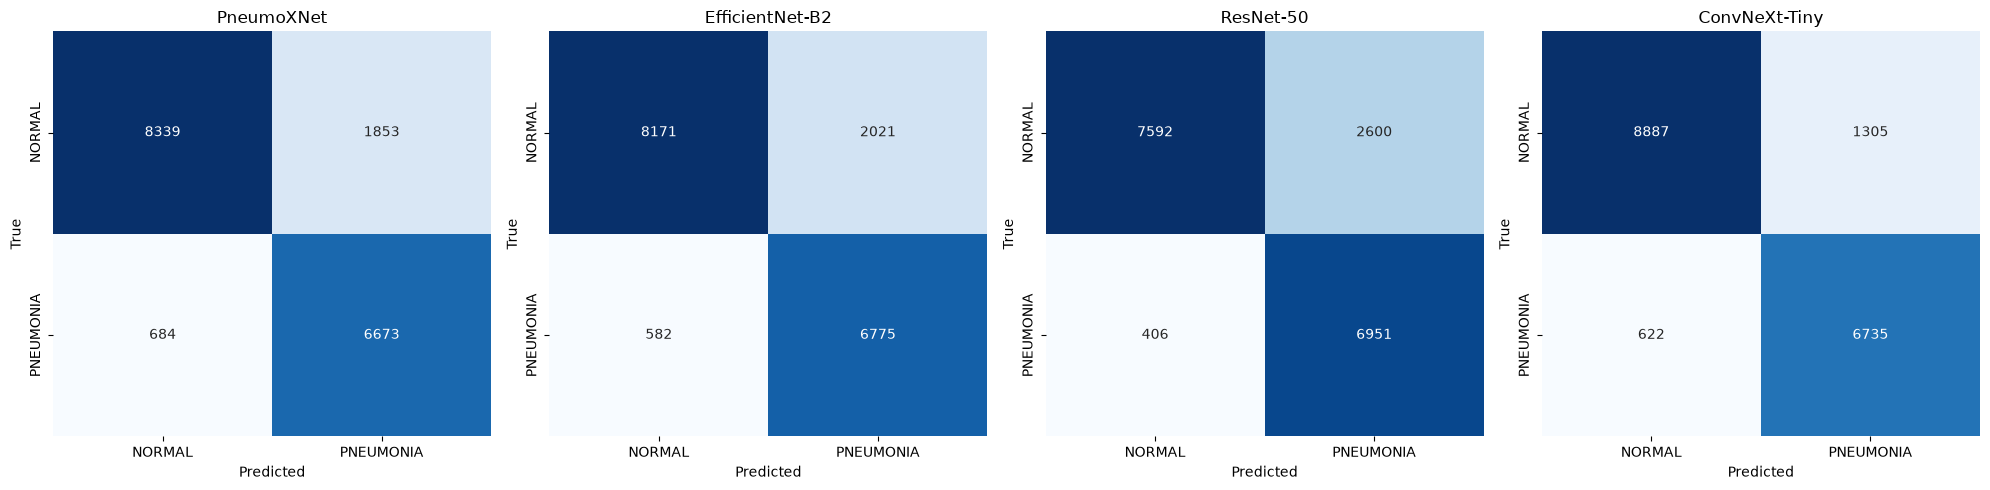

In [8]:
#Cell 8 — Summary Table + Confusion Matrices

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_DIR / "cross_dataset_generalization_results.csv", index=False)

print("=" * 70)
print("Cross-Dataset Generalization Results (COVID-19 Radiography, external, binary)")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (model_name, (y_true, y_pred, y_prob)) in zip(axes, per_model_predictions.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(RESULTS_DIR.parent / "figures" / "cross_dataset_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()